<a href="https://colab.research.google.com/github/sonalisanjeevprabu18/Neural-Network-and-Deep-Learning/blob/main/NNDL_EXP7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train: (56024, 48, 1) | Test: (13971, 48, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0035 - val_loss: 7.1270e-04
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7.3575e-04 - val_loss: 5.0693e-04
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 4.7769e-04 - val_loss: 3.5580e-04
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 3.6321e-04 - val_loss: 2.0513e-04
Epoch 5/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.9068e-04 - val_loss: 2.5994e-04
Epoch 6/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 2.5493e-04 - val_loss: 1.5217e-04
Epoch 7/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.4548e-04 - val_loss: 2.7651e-04
Epoch 8/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 2.3572e-04 - val_loss: 1.7509e-04
Epoch 9/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.2799e-04 - val_loss: 1.5074e-04
Epoch 10/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 2.2081e-04 - val_loss: 1.5506e-04
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

RMSE: 0.77 °C


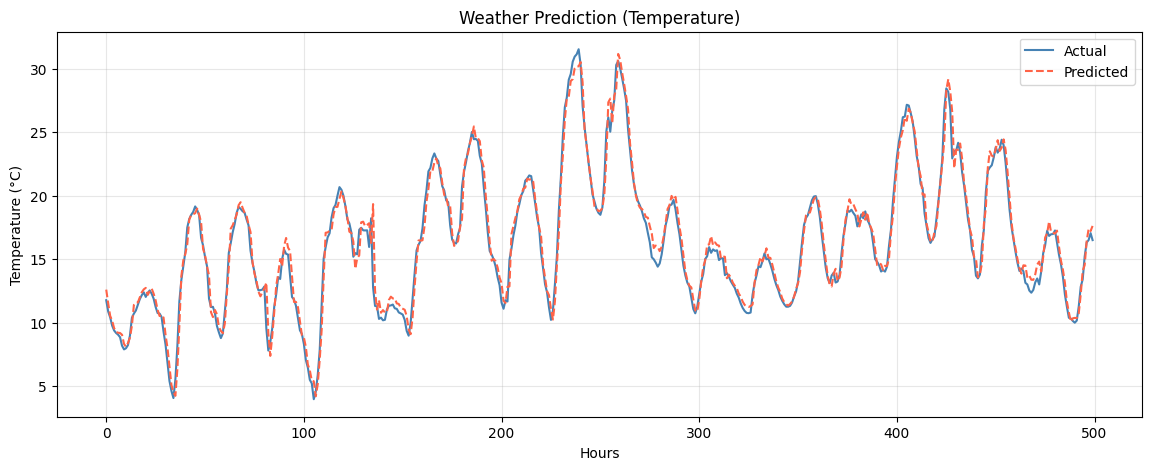

In [1]:
# Weather Prediction using LSTM - Google Colab

!pip install tensorflow pandas numpy matplotlib scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ── Load Data ──────────────────────────────────────────────────────────────────
!wget -q https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
!unzip -q jena_climate_2009_2016.csv.zip

df = pd.read_csv('jena_climate_2009_2016.csv')
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df.set_index('Date Time', inplace=True)
df = df[5::6]  # 10-min → hourly

# Use only temperature column
temp = df[['T (degC)']].values

# ── Preprocess ─────────────────────────────────────────────────────────────────
scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temp)

# Split 80/20
split = int(len(temp_scaled) * 0.8)
train = temp_scaled[:split]
test  = temp_scaled[split:]

# Create sequences: use past 48 hours to predict next hour
def make_sequences(data, seq_len=48):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train)
X_test,  y_test  = make_sequences(test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ── Build Model ────────────────────────────────────────────────────────────────
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(48, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# ── Train
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.1,
                    verbose=1)

# ── Evaluate ───────────────────────────────────────────────────────────────────
y_pred = scaler.inverse_transform(model.predict(X_test))
y_true = scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"\nRMSE: {rmse:.2f} °C")

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_true[:500], label='Actual',    color='steelblue')
plt.plot(y_pred[:500], label='Predicted', color='tomato', linestyle='--')
plt.title('Weather Prediction (Temperature)')
plt.xlabel('Hours'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Data fetched: 1758 hourly records
From: 2026-01-09 18:00:00  To: 2026-03-23 23:00:00
                     temperature  humidity  windspeed  precipitation
time                                                                
2026-03-23 19:00:00         28.1      40.0        5.8            0.0
2026-03-23 20:00:00         26.9      43.0        8.1            0.0
2026-03-23 21:00:00         25.7      48.0        9.4            0.0
2026-03-23 22:00:00         24.8      53.0        8.9            0.0
2026-03-23 23:00:00         24.0      60.0        7.6            0.0


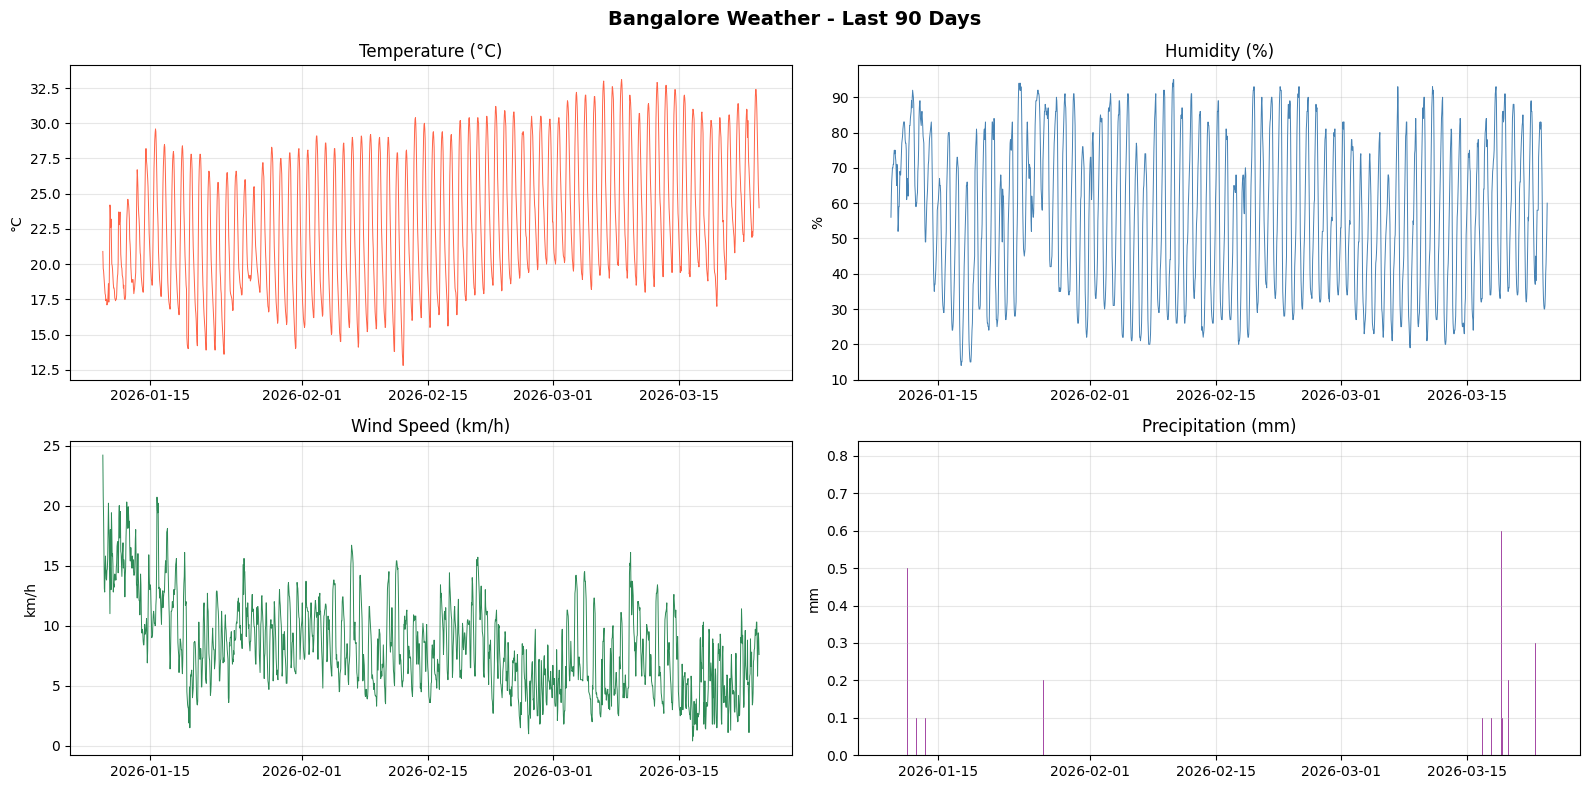


X_train: (1686, 48, 4) | X_test: (24, 48, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 48, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0463 - val_loss: 0.0090
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0121 - val_loss: 0.0038
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0090 - val_loss: 0.0048
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0078 - val_loss: 0.0034
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0066 - val_loss: 0.0030
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0067 - val_loss: 0.0029
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0055 - val_loss: 0.0037
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0058 - val_loss: 0.0036
Epoch 9/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 10/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 - val_loss: 0.0021
Epoch 11/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0049 - val_loss: 0.0025
Epoch 12/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0

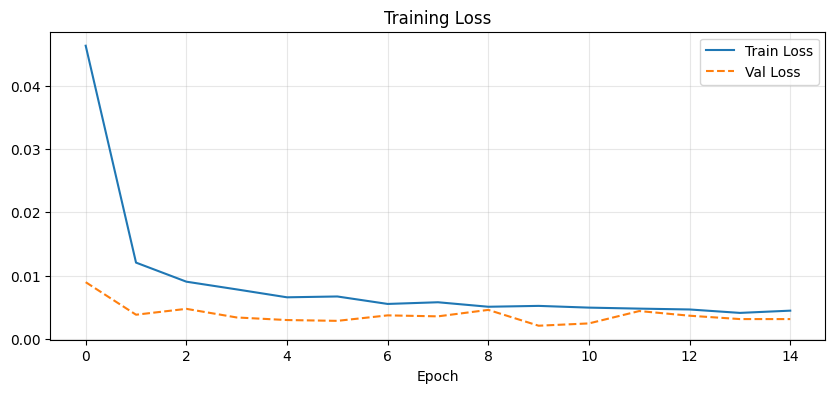


  Today's Prediction Results
  RMSE : 0.66 °C
  MAE  : 0.55 °C

Today's Hourly Temperature — Bangalore
 Hour  Actual (°C)  Predicted (°C)  Error (°C)
00:00         23.8       22.959999        0.84
01:00         23.4       22.480000        0.92
02:00         22.9       22.080000        0.82
03:00         22.4       21.820000        0.58
04:00         21.9       21.760000        0.14
05:00         22.3       21.930000        0.37
06:00         22.0       22.480000        0.48
07:00         22.4       23.379999        0.98
08:00         23.6       24.639999        1.04
09:00         25.3       26.270000        0.97
10:00         27.3       28.020000        0.72
11:00         29.5       29.650000        0.15
12:00         30.9       30.959999        0.06
13:00         31.9       31.680000        0.22
14:00         32.4       31.830000        0.57
15:00         32.4       31.480000        0.92
16:00         31.9       30.809999        1.09
17:00         31.0       29.950001        1.05
18:

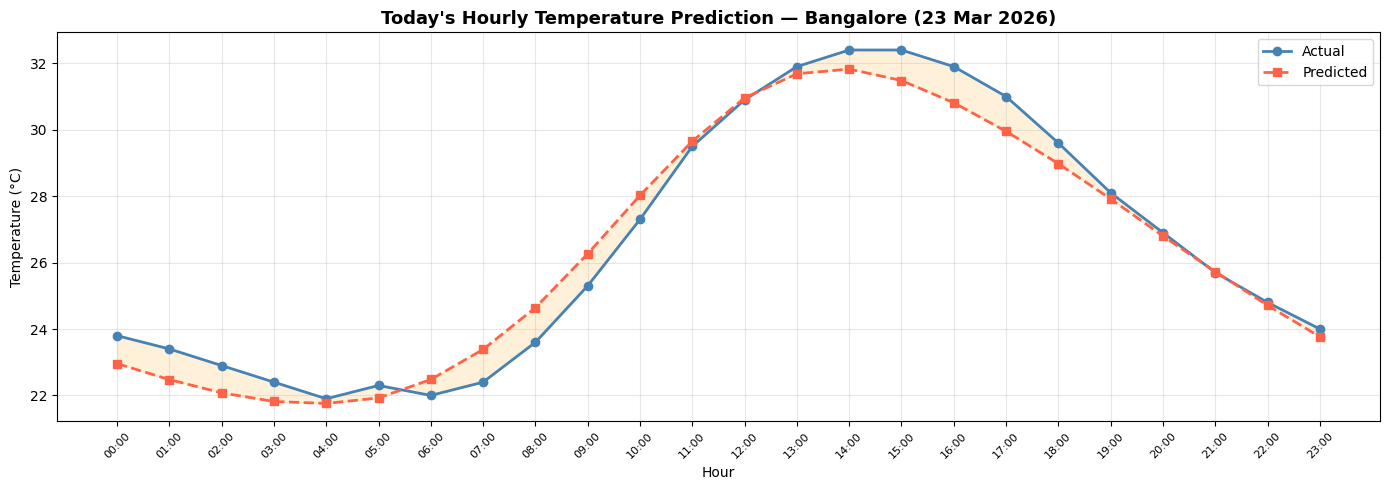


📍 Bangalore Weather Summary for Today
   Min Temp  : 21.8 °C  (at 04:00)
   Max Temp  : 31.8 °C  (at 14:00)
   Avg Temp  : 26.3 °C


In [2]:
# Bangalore Weather Prediction using LSTM
# Uses Open-Meteo API (free, no API key needed)
# Run in Google Colab

!pip install tensorflow pandas numpy matplotlib scikit-learn requests -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from datetime import datetime, timedelta

# ── Fetch Historical Weather Data for Bangalore ────────────────────────────────
# Bangalore coordinates: 12.97°N, 77.59°E
# Fetch last 90 days of hourly temperature data

end_date   = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=90)).strftime('%Y-%m-%d')

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 12.97,
    "longitude": 77.59,
    "hourly": "temperature_2m,relativehumidity_2m,windspeed_10m,precipitation",
    "start_date": start_date,
    "end_date": end_date,
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame({
    "time":        data["hourly"]["time"],
    "temperature": data["hourly"]["temperature_2m"],
    "humidity":    data["hourly"]["relativehumidity_2m"],
    "windspeed":   data["hourly"]["windspeed_10m"],
    "precipitation": data["hourly"]["precipitation"]
})

df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)
df.dropna(inplace=True)

print(f"Data fetched: {df.shape[0]} hourly records")
print(f"From: {df.index[0]}  To: {df.index[-1]}")
print(df.tail())

# ── EDA Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("Bangalore Weather - Last 90 Days", fontsize=14, fontweight='bold')

axes[0,0].plot(df['temperature'], color='tomato', linewidth=0.7)
axes[0,0].set(title='Temperature (°C)', ylabel='°C')
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(df['humidity'], color='steelblue', linewidth=0.7)
axes[0,1].set(title='Humidity (%)', ylabel='%')
axes[0,1].grid(alpha=0.3)

axes[1,0].plot(df['windspeed'], color='seagreen', linewidth=0.7)
axes[1,0].set(title='Wind Speed (km/h)', ylabel='km/h')
axes[1,0].grid(alpha=0.3)

axes[1,1].bar(df.index, df['precipitation'], color='purple', width=0.03, alpha=0.7)
axes[1,1].set(title='Precipitation (mm)', ylabel='mm')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Preprocess ─────────────────────────────────────────────────────────────────
features = ["temperature", "humidity", "windspeed", "precipitation"]
values   = df[features].values

scaler        = MinMaxScaler()
values_scaled = scaler.fit_transform(values)

# Separate scaler for temperature (to inverse transform predictions)
temp_scaler = MinMaxScaler()
temp_scaler.fit(df[["temperature"]].values)

# Train on all but last 24 hours; test on last 24 hours (today)
split    = len(values_scaled) - 24
train    = values_scaled[:split]
test_all = values_scaled  # keep full for building test sequences

# Create sequences: use past 48 hours → predict next hour temperature
SEQ_LEN = 48

def make_sequences(data, seq_len=48):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len, 0])  # index 0 = temperature
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train, SEQ_LEN)

# Test sequences built from full data so last 24 outputs = today's hours
X_all, y_all = make_sequences(test_all, SEQ_LEN)
X_test = X_all[-24:]
y_test = y_all[-24:]

print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")

# ── Build LSTM Model ───────────────────────────────────────────────────────────
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# ── Train ──────────────────────────────────────────────────────────────────────
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Training Loss'); plt.xlabel('Epoch')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# ── Predict Today's Hourly Temperature ────────────────────────────────────────
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = temp_scaler.inverse_transform(y_pred_scaled).flatten()
y_true = temp_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
print(f"\n{'='*40}")
print(f"  Today's Prediction Results")
print(f"  RMSE : {rmse:.2f} °C")
print(f"  MAE  : {mae:.2f} °C")
print(f"{'='*40}")

# ── Today's Hourly Forecast Table ─────────────────────────────────────────────
today_hours = df.index[-24:]
result_df   = pd.DataFrame({
    "Hour":      today_hours.strftime("%H:%M"),
    "Actual (°C)":    np.round(y_true, 2),
    "Predicted (°C)": np.round(y_pred, 2),
    "Error (°C)":     np.round(np.abs(y_true - y_pred), 2)
})
print("\nToday's Hourly Temperature — Bangalore")
print(result_df.to_string(index=False))

# ── Plot Today's Prediction ────────────────────────────────────────────────────
hours_label = today_hours.strftime("%H:%M")

plt.figure(figsize=(14, 5))
plt.plot(range(24), y_true, marker='o', label='Actual',    color='steelblue', linewidth=2)
plt.plot(range(24), y_pred, marker='s', label='Predicted', color='tomato',    linewidth=2, linestyle='--')
plt.fill_between(range(24), y_true, y_pred, alpha=0.15, color='orange')
plt.xticks(range(24), hours_label, rotation=45, fontsize=8)
plt.title(f"Today's Hourly Temperature Prediction — Bangalore ({datetime.today().strftime('%d %b %Y')})",
          fontsize=13, fontweight='bold')
plt.xlabel("Hour"); plt.ylabel("Temperature (°C)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary Stats ──────────────────────────────────────────────────────────────
print(f"\n📍 Bangalore Weather Summary for Today")
print(f"   Min Temp  : {y_pred.min():.1f} °C  (at {hours_label[np.argmin(y_pred)]})")
print(f"   Max Temp  : {y_pred.max():.1f} °C  (at {hours_label[np.argmax(y_pred)]})")
print(f"   Avg Temp  : {y_pred.mean():.1f} °C")